# M - 이부프로펜 단일제

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 이부프로펜 단일제(M그룹) 서브셋 추출
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False, parse_dates=['receive_date'])

def first_segment(s):
    return '' if pd.isna(s) else s.split(';')[0]

df['first_seg'] = df['suspect_drug'].apply(first_segment)
drug_pat = re.compile(r'IBUPROFEN|BRUFEN|NUROFEN|ADVIL|MOTRIN', re.I)
ibu = df[(df['WHO_ATC'] == 'M') & df['first_seg'].apply(lambda x: bool(drug_pat.search(x)))].copy()
ibu['is_serious'] = ibu['serious'] == 'Yes'
print(f'분석 대상: {len(ibu)}건')

age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
age_labels = ['영유아\n0-2', '소아\n3-12', '청소년\n13-18', '성인\n19-40',
              '중년\n41-65', '장년\n66-80', '고령\n81+']
core = ibu[ibu['age_group'].isin(age_order)].copy()

분석 대상: 1345건


상위 15개 반응이 차지하는 비율: 25.3%
나머지 504종의 반응이 차지하는 비율: 74.7%


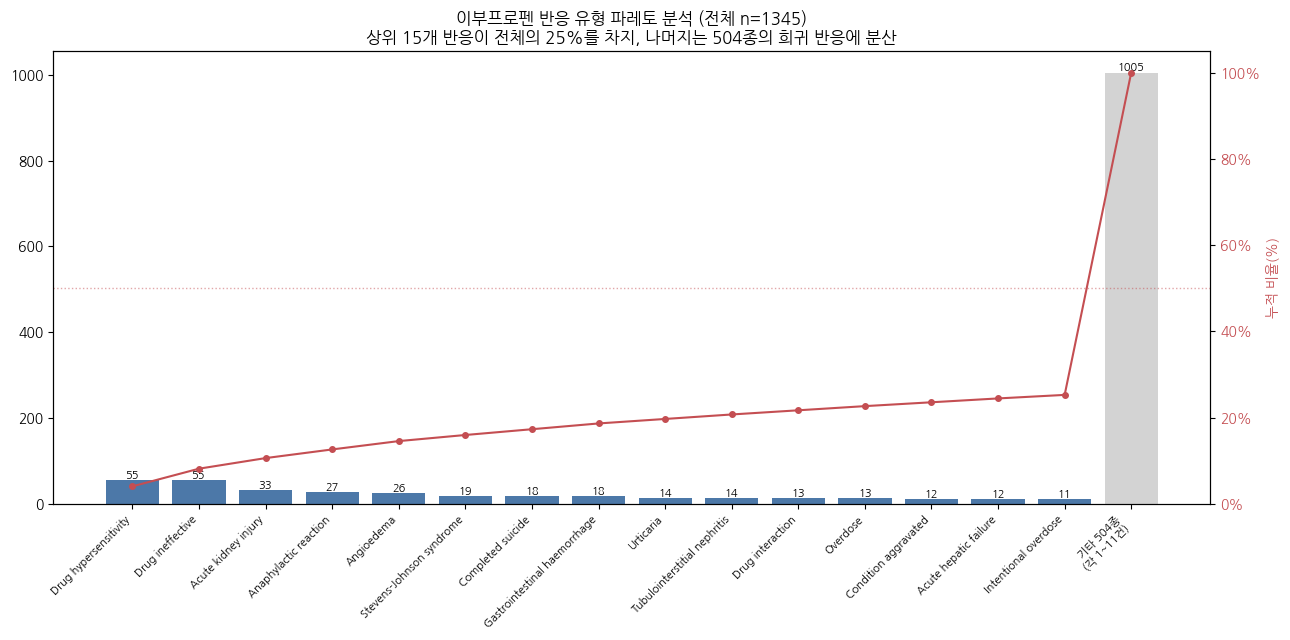

In [2]:
# 반응 유형 롱테일(파레토) 분석
top_n = 15
vc = ibu['primary_reaction'].value_counts()
top = vc.head(top_n)
rest_count = vc.iloc[top_n:].sum()
rest_n_types = vc.iloc[top_n:].shape[0]
n_total = len(ibu)

print(f'상위 {top_n}개 반응이 차지하는 비율: {top.sum()/n_total*100:.1f}%')
print(f'나머지 {rest_n_types}종의 반응이 차지하는 비율: {rest_count/n_total*100:.1f}%')

labels = list(top.index) + [f'기타 {rest_n_types}종\n(각 1~{vc.iloc[top_n:].max()}건)']
values = list(top.values) + [rest_count]
cum_pct = np.cumsum(values) / n_total * 100

fig, ax1 = plt.subplots(figsize=(13, 6.5))
bar_colors = ['#4C78A8'] * top_n + ['#D3D3D3']
bars = ax1.bar(range(len(labels)), values, color=bar_colors)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
for b, v in zip(bars, values):
    ax1.text(b.get_x() + b.get_width()/2, v + 3, str(v), ha='center', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(labels)), cum_pct, color='#C44E52', marker='o', markersize=4)
ax2.set_ylabel('누적 비율(%)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.axhline(50, color='#C44E52', linestyle=':', linewidth=1, alpha=0.5)

ax1.set_title(
    f'이부프로펜 반응 유형 파레토 분석 (전체 n={n_total})\n'
    f'상위 {top_n}개 반응이 전체의 {cum_pct[top_n-1]:.0f}%를 차지, 나머지는 {rest_n_types}종의 희귀 반응에 분산'
)
plt.tight_layout()
plt.show()

연령 그룹별 n: {'Infant(0-2)': 43, 'Child(3-12)': 75, 'Teen(13-18)': 86, 'Adult(19-40)': 201, 'Middle-Aged(41-65)': 417, 'Senior(66-80)': 170, 'Elderly(81+)': 59}

[카테고리별 카이제곱 검정 결과]
  신장/전해질: p=0.3015 
  알레르기/피부: p=0.0170 *
  중증피부반응: p=0.0028 *
  위장관: p=0.0044 *
  간담도: p=0.0043 *
  자해/정신과적: p=0.6666 
  과다복용/중독(의도불명): p=0.0041 *
  약물사용 관련(오남용·무효·오투여): p=0.0209 *
  호흡기/질식: p=0.2913 
  감염/패혈증: p=0.0046 *
  심혈관: p=0.1576 
  사망(원인 미상): p=0.4311 


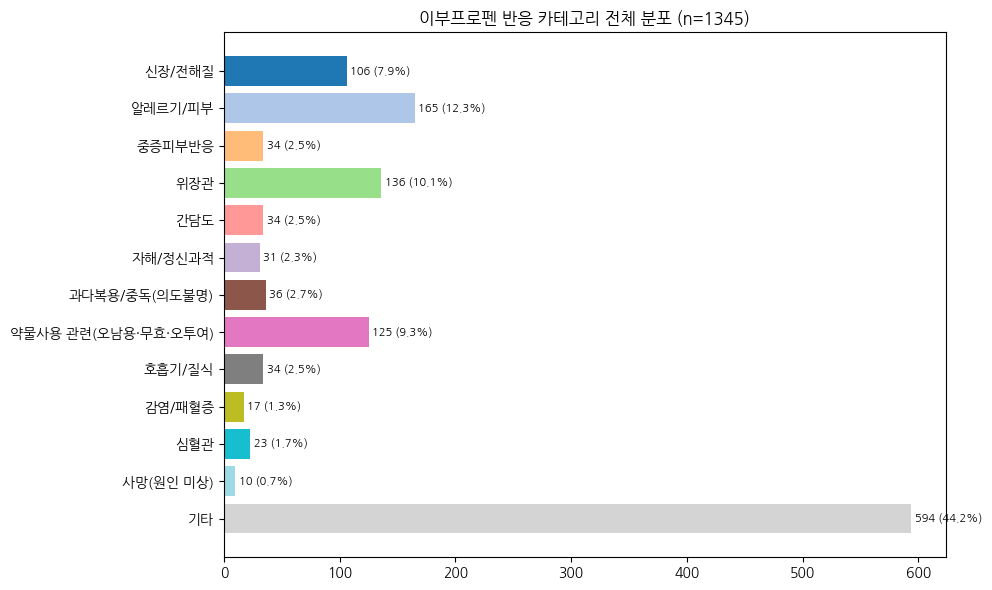

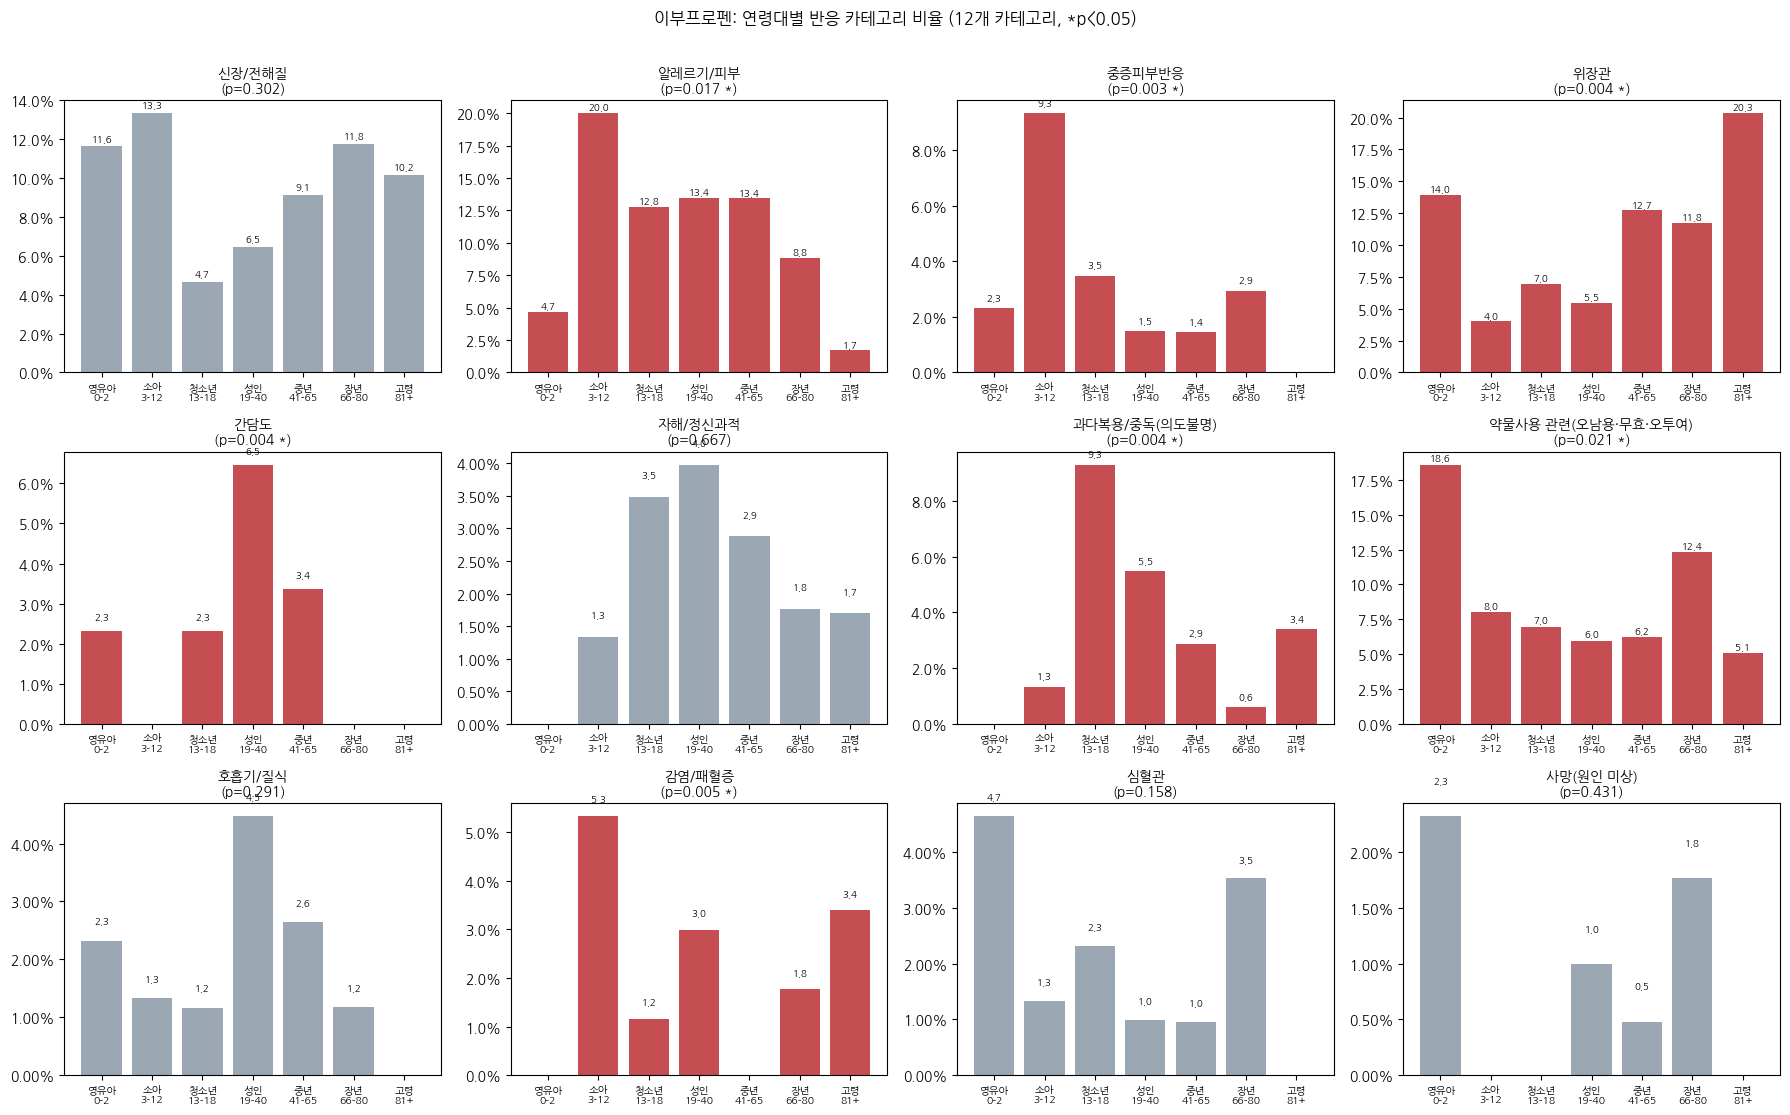

In [3]:
# 12개 반응 카테고리 분류 및 연령대별 분포
cats = [
    ('신장/전해질',                    r'kidney|renal|nephritis|nephropathy|creatinine|metabolic acidosis|electrolyte|hyperkalaemia'),
    ('알레르기/피부',                  r'hypersensitivity|anaphyla|angioedema|urticaria|\brash\b|eruption|pruritus|dermatitis'),
    ('중증피부반응',                   r'stevens|toxic epidermal|erythema multiforme|dress\b|eosinophilia and systemic'),
    ('위장관',                        r'haemorrhage|hemorrhage|nausea|vomit|abdominal|colitis|ulcer|gastritis|melaena|diarrhoea|constipation'),
    ('간담도',                        r'hepatic|liver|jaundice|bilirubin'),
    ('자해/정신과적',                  r'suicide|self.?harm|self.?injur|depression|anxiety'),
    ('과다복용/중독(의도불명)',          r'\boverdose\b|toxicity to various agents|poisoning'),
    ('약물사용 관련(오남용·무효·오투여)', r'ineffective|abuse|dependence|off label|misuse|incorrect dose|extra dose|accidental exposure|product use'),
    ('호흡기/질식',                    r'choking|dyspnoea|respiratory|asthma|bronch'),
    ('감염/패혈증',                    r'sepsis|infection|pneumonia'),
    ('심혈관',                        r'cardiac|hypertension|tachycardia|myocardial|arrhythmia'),
    ('사망(원인 미상)',                r'^death$'),
]

def classify(r):
    if pd.isna(r):
        return '기타'
    for name, pat in cats:
        if re.search(pat, r, re.I):
            return name
    return '기타'

ibu['category'] = ibu['primary_reaction'].apply(classify)
core['category'] = core['primary_reaction'].apply(classify)

print(f'연령 그룹별 n: {core["age_group"].value_counts().reindex(age_order).to_dict()}')
print('\n[카테고리별 카이제곱 검정 결과]')
pvalues = {}
for name, pat in cats:
    core[name] = core['category'] == name
    ct = pd.crosstab(core['age_group'], core[name]).reindex(age_order)
    try:
        chi2, p, dof, _ = chi2_contingency(ct)
    except Exception:
        p = float('nan')
    pvalues[name] = p
    sig = '*' if p == p and p < 0.05 else ''
    print(f'  {name}: p={p:.4f} {sig}')

# 전체 카테고리 분포
order_all = [c[0] for c in cats] + ['기타']
vc_all = ibu['category'].value_counts().reindex(order_all)

fig1, ax = plt.subplots(figsize=(10, 6))
colors12 = plt.cm.tab20(np.linspace(0, 1, 12)).tolist() + [(0.83, 0.83, 0.83, 1)]
bars = ax.barh(vc_all.index[::-1], vc_all.values[::-1], color=colors12[::-1])
ax.set_title(f'이부프로펜 반응 카테고리 전체 분포 (n={len(ibu)})')
for b, v in zip(bars, vc_all.values[::-1]):
    ax.text(b.get_width() + 3, b.get_y() + b.get_height()/2, f'{v} ({v/len(ibu)*100:.1f}%)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# 연령대별 12개 카테고리 소그래프
fig2, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, (name, pat) in zip(axes, cats):
    rate = core.groupby('age_group')[name].mean().reindex(age_order) * 100
    p = pvalues[name]
    sig = (p == p) and (p < 0.05)
    color = '#C44E52' if sig else '#9BA8B4'
    bars = ax.bar(age_labels, rate.values, color=color)
    title_suffix = (f'p={p:.3f}' + (' *' if sig else '')) if p == p else 'p=n/a'
    ax.set_title(f'{name}\n({title_suffix})', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', labelsize=7.5)
    for b, v in zip(bars, rate.values):
        if v > 0:
            ax.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=7)

fig2.suptitle('이부프로펜: 연령대별 반응 카테고리 비율 (12개 카테고리, *p<0.05)', y=1.01)
plt.tight_layout()
plt.show()

카이제곱 검정: p = 0.00001
age_group
Infant(0-2)           72.1
Child(3-12)           81.3
Teen(13-18)           96.5
Adult(19-40)          93.5
Middle-Aged(41-65)    82.0
Senior(66-80)         79.4
Elderly(81+)          81.4
Name: is_serious, dtype: float64


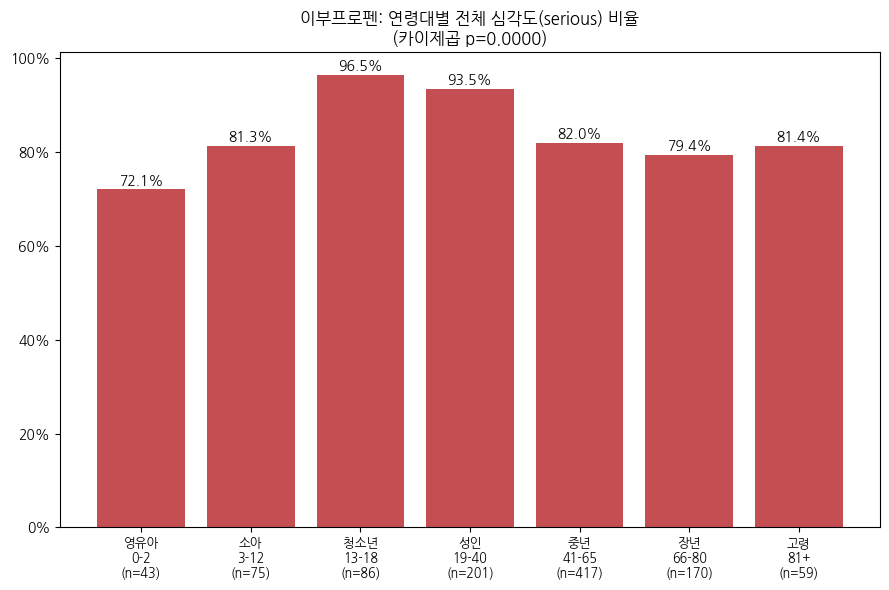

In [4]:
# 연령대별 전체 심각도(serious) 비율
ns = core['age_group'].value_counts().reindex(age_order)
rate = core.groupby('age_group')['is_serious'].mean().reindex(age_order) * 100
ct = pd.crosstab(core['age_group'], core['is_serious']).reindex(age_order)
chi2, p, dof, _ = chi2_contingency(ct)
print(f'카이제곱 검정: p = {p:.5f}')
print(rate.round(1))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar([f'{l}\n(n={n})' for l, n in zip(age_labels, ns.values)], rate.values, color='#C44E52')
ax.set_title(f'이부프로펜: 연령대별 전체 심각도(serious) 비율\n(카이제곱 p={p:.4f})')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', labelsize=9)
for b, v in zip(bars, rate.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

                    lifethreat  hosp  selfharm    gi
age_group                                           
Infant(0-2)               11.6  41.9       0.0  11.6
Child(3-12)                9.3  48.0       0.0   2.7
Teen(13-18)               19.8  50.0       9.3   5.8
Adult(19-40)              17.9  52.7       6.5   3.0
Middle-Aged(41-65)        10.3  47.0       5.3   8.4
Senior(66-80)              4.1  55.9       1.8   7.1
Elderly(81+)               0.0  64.4       3.4  16.9


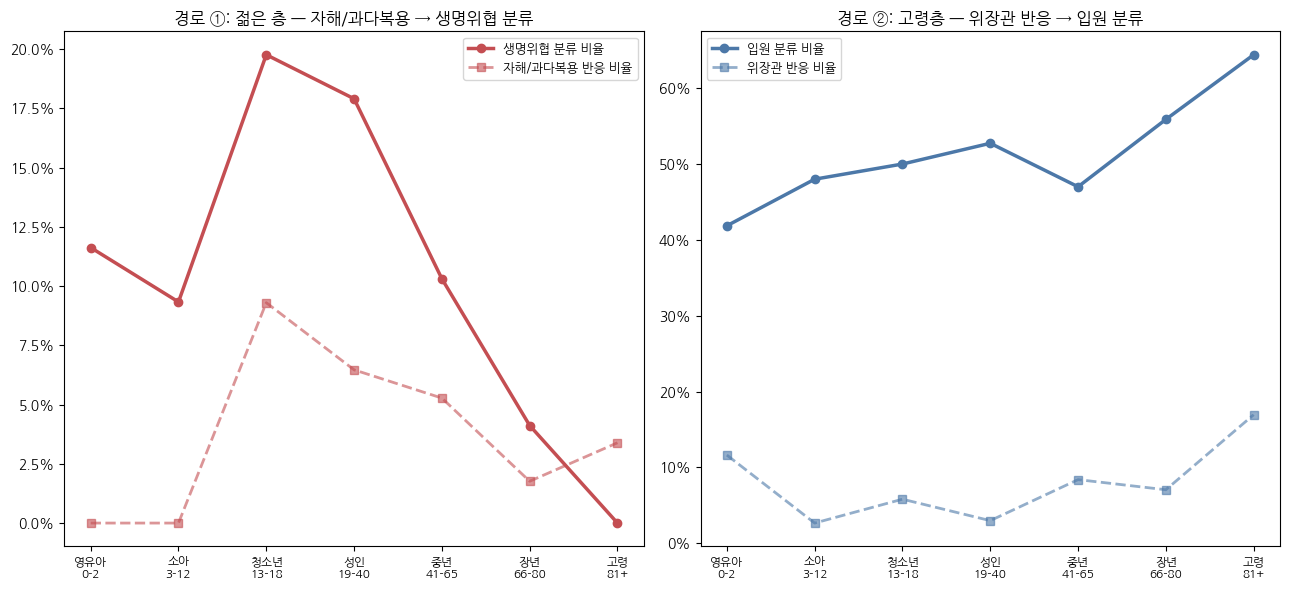

In [5]:
# 연령대별 "두 갈래 위험 경로": 젊은층(자해/과다복용→생명위협) vs 고령층(위장관→입원)
core['is_selfharm'] = core['primary_reaction'].str.contains('suicide|overdose|self.?harm', case=False, na=False)
core['is_gi'] = core['primary_reaction'].str.contains('haemorrhage|hemorrhage|gastritis|ulcer|melaena', case=False, na=False)

out = core.groupby('age_group').agg(
    lifethreat=('is_life_threat', 'mean'), hosp=('is_hospitalized', 'mean'),
    selfharm=('is_selfharm', 'mean'), gi=('is_gi', 'mean'),
).reindex(age_order) * 100
print(out.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax1 = axes[0]
ax1.plot(age_labels, out['lifethreat'], marker='o', color='#C44E52', linewidth=2.5, label='생명위협 분류 비율')
ax1.plot(age_labels, out['selfharm'], marker='s', color='#C44E52', linewidth=2, linestyle='--', alpha=0.6, label='자해/과다복용 반응 비율')
ax1.set_title('경로 ①: 젊은 층 — 자해/과다복용 → 생명위협 분류')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=9); ax1.tick_params(axis='x', labelsize=8.5)

ax2 = axes[1]
ax2.plot(age_labels, out['hosp'], marker='o', color='#4C78A8', linewidth=2.5, label='입원 분류 비율')
ax2.plot(age_labels, out['gi'], marker='s', color='#4C78A8', linewidth=2, linestyle='--', alpha=0.6, label='위장관 반응 비율')
ax2.set_title('경로 ②: 고령층 — 위장관 반응 → 입원 분류')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9); ax2.tick_params(axis='x', labelsize=8.5)

plt.tight_layout()
plt.show()

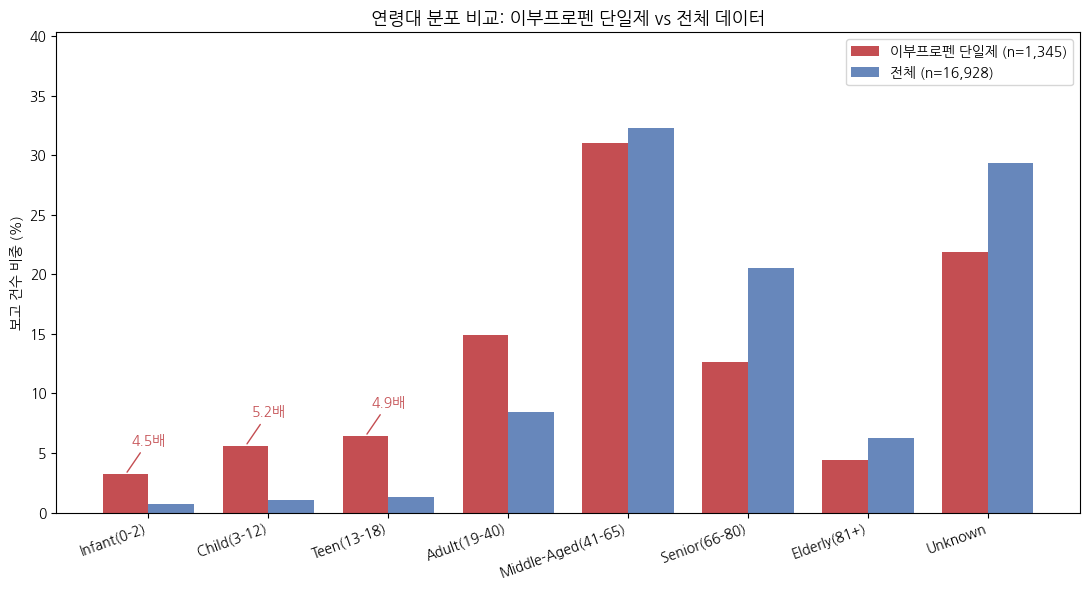

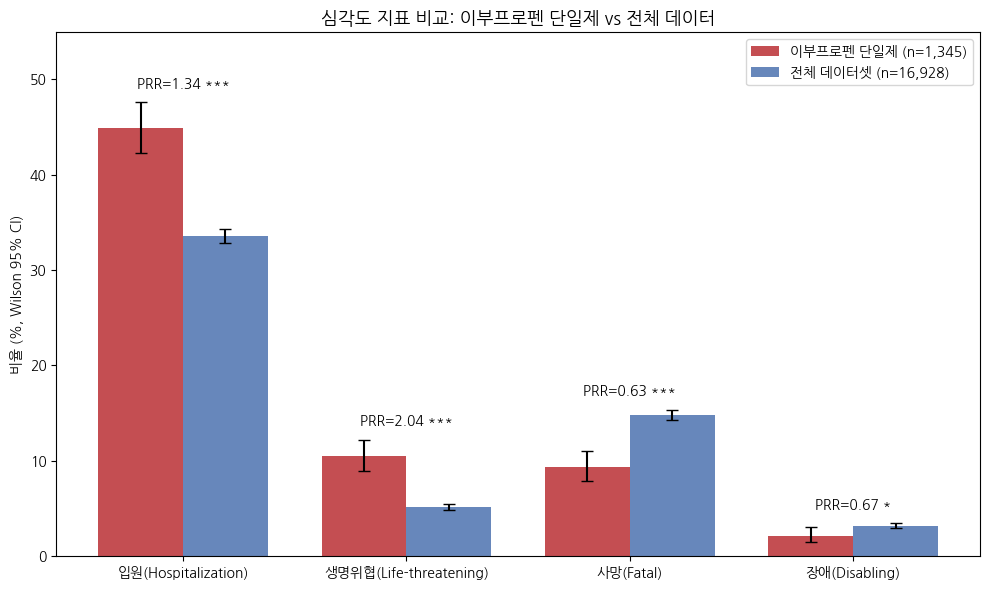

=== 요약 ===
입원(Hospitalization)       이부프로펜 44.9% vs 전체 33.5%  PRR=1.34  p=1.1e-16
생명위협(Life-threatening)    이부프로펜 10.5% vs 전체 5.1%  PRR=2.04  p=7.6e-14
사망(Fatal)                 이부프로펜 9.4% vs 전체 14.8%  PRR=0.63  p=9.3e-09
장애(Disabling)             이부프로펜 2.2% vs 전체 3.2%  PRR=0.67  p=3.4e-02

연령대 배수(이부프로펜/전체):
  Infant(0-2): 4.5배
  Child(3-12): 5.2배
  Teen(13-18): 4.9배


In [10]:

from scipy.stats import fisher_exact

RED = '#C44E52'   # 이부프로펜
BLUE = '#4C72B0'  # 전체 데이터

df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
m = df[df['WHO_ATC'] == 'M'].copy()
sd = m['suspect_drug'].str.upper()
ibu_mask = sd.str.contains('IBUPROFEN|ADVIL|MOTRIN|NUROFEN|BRUFEN', na=False) & \
           ~sd.str.contains('NAPROXEN|DICLOFENAC', na=False)
ibu = m[ibu_mask].copy()
rest = df[~df.index.isin(ibu.index)].copy()

n_ibu, n_rest = len(ibu), len(rest)

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (center - margin) / denom, (center + margin) / denom

# 연령대 분포 비교
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']

ibu_age = ibu['age_group'].value_counts(normalize=True).reindex(age_order).fillna(0) * 100
rest_age = rest['age_group'].value_counts(normalize=True).reindex(age_order).fillna(0) * 100
ratio = (ibu_age / rest_age).replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(age_order))
w = 0.38

bars_ibu = ax.bar(x - w/2, ibu_age, width=w, color=RED, label=f'이부프로펜 단일제 (n={n_ibu:,})')
bars_rest = ax.bar(x + w/2, rest_age, width=w, color=BLUE, alpha=0.85, label=f'전체 (n={n_rest:,})')

ax.set_xticks(x)
ax.set_xticklabels(age_order, rotation=20, ha='right')
ax.set_ylabel('보고 건수 비중 (%)')
ax.set_title('연령대 분포 비교: 이부프로펜 단일제 vs 전체 데이터', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

# 소아/청소년 구간에 배수(ratio) 주석
highlight_groups = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)']
for g in highlight_groups:
    i = age_order.index(g)
    top = max(ibu_age[g], rest_age[g])
    ax.annotate(f'{ratio[g]:.1f}배', xy=(i - w/2, ibu_age[g]),
                xytext=(i, top + 2.5), ha='center', fontsize=10, fontweight='bold', color=RED,
                arrowprops=dict(arrowstyle='-', color=RED, lw=1))

ax.set_ylim(0, max(ibu_age.max(), rest_age.max()) + 8)
plt.tight_layout()
plt.show()

# 심각도 지표 비교 (PRR + Wilson 95% CI)
metrics = [
    ('is_hospitalized', '입원(Hospitalization)'),
    ('is_life_threat', '생명위협(Life-threatening)'),
    ('is_fatal', '사망(Fatal)'),
    ('is_disabling', '장애(Disabling)'),
]

results = []
for col, label in metrics:
    k1 = ibu[col].sum() if ibu[col].dtype == bool else (ibu[col] == 'Yes').sum()
    k2 = rest[col].sum() if rest[col].dtype == bool else (rest[col] == 'Yes').sum()
    p1, p2 = k1 / n_ibu, k2 / n_rest
    prr = p1 / p2
    _, p_fisher = fisher_exact([[k1, n_ibu - k1], [k2, n_rest - k2]])
    lo1, hi1 = wilson_ci(k1, n_ibu)
    lo2, hi2 = wilson_ci(k2, n_rest)
    results.append(dict(label=label, p1=p1*100, p2=p2*100, prr=prr, p_fisher=p_fisher,
                         err1=(p1*100-lo1*100, hi1*100-p1*100), err2=(p2*100-lo2*100, hi2*100-p2*100)))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
w = 0.38

p1_vals = [r['p1'] for r in results]
p2_vals = [r['p2'] for r in results]
err1 = np.array([r['err1'] for r in results]).T
err2 = np.array([r['err2'] for r in results]).T

ax.bar(x - w/2, p1_vals, width=w, color=RED, yerr=err1, capsize=4,
       label=f'이부프로펜 단일제 (n={n_ibu:,})')
ax.bar(x + w/2, p2_vals, width=w, color=BLUE, alpha=0.85, yerr=err2, capsize=4,
       label=f'전체 데이터셋 (n={n_rest:,})')

ax.set_xticks(x)
ax.set_xticklabels([r['label'] for r in results])
ax.set_ylabel('비율 (%, Wilson 95% CI)')
ax.set_title('심각도 지표 비교: 이부프로펜 단일제 vs 전체 데이터', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

# PRR 및 유의성 주석
for i, r in enumerate(results):
    top = max(r['p1'] + r['err1'][1], r['p2'] + r['err2'][1])
    sig = '***' if r['p_fisher'] < 0.001 else ('**' if r['p_fisher'] < 0.01 else ('*' if r['p_fisher'] < 0.05 else 'ns'))
    ax.text(i, top + 1.5, f"PRR={r['prr']:.2f} {sig}", ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, max(p1_vals + p2_vals) + 10)
plt.tight_layout()
plt.show()

print("=== 요약 ===")
for r in results:
    print(f"{r['label']:25s} 이부프로펜 {r['p1']:.1f}% vs 전체 {r['p2']:.1f}%  PRR={r['prr']:.2f}  p={r['p_fisher']:.1e}")
print()
print("연령대 배수(이부프로펜/전체):")
for g in highlight_groups:
    print(f"  {g}: {ratio[g]:.1f}배")

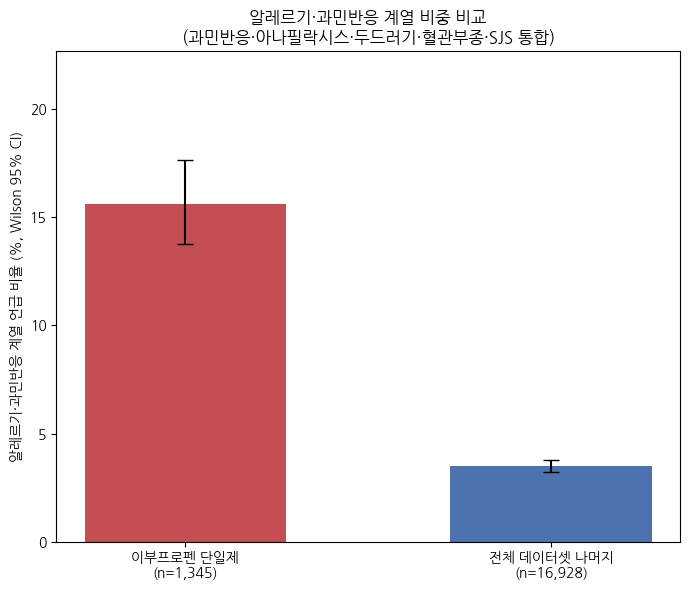

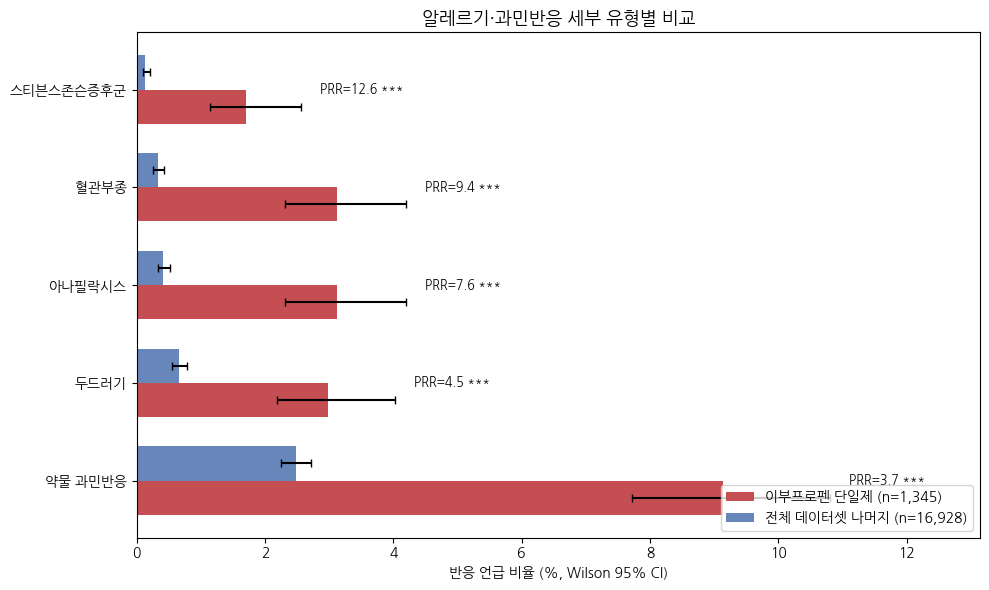

=== 알레르기·과민반응 계열 종합 ===
이부프로펜 15.6% vs 전체 나머지 3.5%  PRR=4.43  p=3.1e-63

=== 세부 유형별 (PRR 오름차순) ===
약물 과민반응         이부프로펜 9.14% vs 전체 2.48%  PRR=3.69  p=1.9e-30
두드러기            이부프로펜 2.97% vs 전체 0.66%  PRR=4.54  p=5.4e-13
아나필락시스          이부프로펜 3.12% vs 전체 0.41%  PRR=7.55  p=1.0e-19
혈관부종            이부프로펜 3.12% vs 전체 0.33%  PRR=9.44  p=2.3e-22
스티븐스존슨증후군       이부프로펜 1.71% vs 전체 0.14%  PRR=12.59  p=1.1e-14


In [15]:

RED = '#C44E52'   # 이부프로펜 단일제
BLUE = '#4C72B0'  # 전체 데이터

df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
m = df[df['WHO_ATC'] == 'M'].copy()
sd = m['suspect_drug'].str.upper()
ibu_mask = sd.str.contains('IBUPROFEN|ADVIL|MOTRIN|NUROFEN|BRUFEN', na=False) & \
           ~sd.str.contains('NAPROXEN|DICLOFENAC', na=False)
ibu = m[ibu_mask].copy()
rest = df[~df.index.isin(ibu.index)].copy()
n_ibu, n_rest = len(ibu), len(rest)

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (center - margin) / denom, (center + margin) / denom

def stat_pair(pattern, group=ibu, base=rest):
    k1 = group['reactions'].str.contains(pattern, case=False, na=False).sum()
    k2 = base['reactions'].str.contains(pattern, case=False, na=False).sum()
    n1, n2 = len(group), len(base)
    p1, p2 = k1 / n1, k2 / n2
    prr = p1 / p2 if p2 > 0 else np.nan
    _, p_fisher = fisher_exact([[k1, n1 - k1], [k2, n2 - k2]])
    lo1, hi1 = wilson_ci(k1, n1)
    lo2, hi2 = wilson_ci(k2, n2)
    return dict(p1=p1*100, p2=p2*100, prr=prr, p_fisher=p_fisher,
                err1=(p1*100-lo1*100, hi1*100-p1*100), err2=(p2*100-lo2*100, hi2*100-p2*100))

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

#  알레르기·과민반응 계열
overall_pattern = 'hypersensitiv|anaphyla|urticaria|angioedema|Stevens-Johnson'
r_overall = stat_pair(overall_pattern)

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(['이부프로펜 단일제\n(n={:,})'.format(n_ibu), '전체 데이터셋 나머지\n(n={:,})'.format(n_rest)],
              [r_overall['p1'], r_overall['p2']],
              color=[RED, BLUE],
              yerr=[[r_overall['err1'][0], r_overall['err2'][0]],
                    [r_overall['err1'][1], r_overall['err2'][1]]],
              capsize=6, width=0.55)

ax.set_ylabel('알레르기·과민반응 계열 언급 비율 (%, Wilson 95% CI)')
ax.set_title('알레르기·과민반응 계열 비중 비교\n(과민반응·아나필락시스·두드러기·혈관부종·SJS 통합)',
              fontsize=12, fontweight='bold')

top = max(r_overall['p1'] + r_overall['err1'][1], r_overall['p2'] + r_overall['err2'][1])
ax.set_ylim(0, top + 5)
plt.tight_layout()
plt.show()

# 세부 반응 유형별 분해
subcats = [
    ('hypersensitiv', '약물 과민반응'),
    ('urticaria', '두드러기'),
    ('anaphyla', '아나필락시스'),
    ('angioedema', '혈관부종'),
    ('Stevens-Johnson', '스티븐스존슨증후군'),
]

rows = []
for pattern, label in subcats:
    r = stat_pair(pattern)
    r['label'] = label
    rows.append(r)

rows.sort(key=lambda r: r['prr'])

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rows))
h = 0.35

p1_vals = [r['p1'] for r in rows]
p2_vals = [r['p2'] for r in rows]
err1 = np.array([r['err1'] for r in rows]).T
err2 = np.array([r['err2'] for r in rows]).T

ax.barh(y - h/2, p1_vals, height=h, color=RED, xerr=err1, capsize=3,
        label=f'이부프로펜 단일제 (n={n_ibu:,})')
ax.barh(y + h/2, p2_vals, height=h, color=BLUE, alpha=0.85, xerr=err2, capsize=3,
        label=f'전체 데이터셋 나머지 (n={n_rest:,})')

ax.set_yticks(y)
ax.set_yticklabels([r['label'] for r in rows])
ax.set_xlabel('반응 언급 비율 (%, Wilson 95% CI)')
ax.set_title('알레르기·과민반응 세부 유형별 비교', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

for i, r in enumerate(rows):
    right = max(r['p1'] + r['err1'][1], r['p2'] + r['err2'][1])
    ax.text(right + 0.3, i, f"PRR={r['prr']:.1f} {sig_stars(r['p_fisher'])}",
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, max(p1_vals + p2_vals) + 4)
plt.tight_layout()
plt.show()

print("=== 알레르기·과민반응 계열 종합 ===")
print(f"이부프로펜 {r_overall['p1']:.1f}% vs 전체 나머지 {r_overall['p2']:.1f}%  PRR={r_overall['prr']:.2f}  p={r_overall['p_fisher']:.1e}")
print()
print("=== 세부 유형별 (PRR 오름차순) ===")
for r in rows:
    print(f"{r['label']:15s} 이부프로펜 {r['p1']:.2f}% vs 전체 {r['p2']:.2f}%  PRR={r['prr']:.2f}  p={r['p_fisher']:.1e}")